# Computer Vision Lab 03 — Edge Detection and Classification

**Google Colab notebook | Muhammad Asad Mashood | Run from top to bottom**

### The main question
Can a classifier identify a skin-lesion image more accurately from its original colors, a filtered image, or an image containing only edges? We will measure all three under the **same Lab 03 split**. This notebook completes each task in the supplied Lab 03 handout: edge-detector comparison; noise and filtering; Canny parameters; three image representations; five classifiers; results, figures, tables, report and viva preparation.

### How this relates to your earlier work

| Notebook | Actual source and classes | Relationship to these results |
|---|---|---|
| Lab 01 | ISIC nine-class source; five selected classes | Different dataset/classes; old scores cannot be placed directly beside this lab's scores. |
| Lab 02 | HAM10000; seven classes; 500-image cap per class, 2,584 images; 224×224 | This notebook adopts the **same source, classes, cap, and image size**. |
| Lab 03 (this notebook) | HAM10000, seven classes, three image representations | It makes a **new lesion-aware split** unless you provide a saved split CSV. It retrains all representations here for an internally fair comparison. |

Lab 02 sampled and split images by image label; this notebook groups images by `lesion_id` to prevent the same lesion appearing in train and test. Thus even its HAM10000 scores are **new scores, not historical Lab 02 scores**. Its default filtered condition is Gaussian, one method evaluated in Lab 02; the Lab 02 winner differs by model. You can edit it after reviewing your Lab 02 results. A fixed Canny setting is a starting example; inspect the training images before finalizing it.


## 0. Understand the experiment before coding

An **image** is a grid of pixels. In a grayscale image, a pixel is one brightness number from 0 (black) to 255 (white). In an RGB image, each pixel has three numbers (red, green, blue). For example, a 224×224 RGB image has shape `(224, 224, 3)`.

An **edge** is a sharp brightness change, often at a lesion boundary, a hair, or a texture line. Along a row, `20, 20, 20, 220, 220` has a sharp transition from 20 to 220. A **kernel** is a small matrix, usually 3×3 or 5×5, applied around each pixel. A smoothing kernel reduces isolated changes; an edge kernel measures changes. This neighborhood calculation is often called convolution in image processing.

**The learning pipeline:** image → representation (raw / filtered / edge) → model → predicted class. The **label** is the correct class in the metadata. **Training** adjusts a model's weights using labeled examples; **validation** chooses settings; the untouched **test set** estimates performance. An **epoch** means one pass through the training set; a **batch** is a smaller group of images. A **CNN** learns useful kernels, so manually supplied edge images can either help or remove information it needs.

**Controlled comparison:** keep the same selected image IDs, labels, train/validation/test split, model architecture and training settings for all three input versions. Only the image representation changes. Each model is trained **from a fresh start** for each input.

### A 30-second worked example of an edge

Suppose neighboring grayscale pixels are `[10, 12, 15, 210, 212]`: the jump from 15 to 210 suggests a strong edge. If we add random noise and obtain `[10, 45, 15, 210, 195]`, we might see extra small changes. Smoothing reduces some of these changes before edge detection. A boundary may also be a hair or an internal texture line, so a visually bright edge does **not** guarantee the correct classification. The notebook will let you compare actual examples and their measured classification results.

###  Install/import tools and set random seeds

**What this does:** installs small missing libraries, imports image-processing (`OpenCV`), analysis (`NumPy`, `pandas`), plotting (`Matplotlib`), and machine-learning packages. A fixed random seed makes splits and initialization more reproducible. TensorFlow is imported later only when we reach deep learning.

In [58]:
%pip -q install kagglehub opencv-python-headless scikit-learn pandas matplotlib seaborn

import os, random, time, gc, json, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
print('OpenCV:', cv2.__version__)
print('Ready: image processing and machine-learning packages imported.')

OpenCV: 5.0.0
Ready: image processing and machine-learning packages imported.


###  Set the dataset and experimental choices

**What this code does:** stores all settings in one place. The defaults reproduce Lab 02's HAM10000 image selection: seven diagnostic classes, at most 500 images per class, 224×224 pixels and eight CNN epochs. `CLASSICAL_SIZE` applies only to SVM/forest/KNN features, not to the CNN images. You may provide an existing `image_id,split` CSV **only if it contains the exact same selected image IDs and keeps each lesion in one split**.

**Before your final run:** confirm which Lab 02 filter you want to compare. The default Gaussian blur uses the Lab 02 5×5 kernel. Change it to `sharpen` if that best supports your chosen Lab 02 model. If you reduce `MAX_IMAGES_PER_CLASS` for practice, restore 500 and rerun from the top for your submission.

In [59]:
DATA_SOURCE = 'kagglehub'
DATA_ROOT = '/content/HAM10000'
SELECTED_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
MAX_IMAGES_PER_CLASS = 500
SPLIT_CSV_PATH = ''
LAB02_FILTER = 'gaussian'      # 5×5 Gaussian; or 'median','mean','sharpen'
IMAGE_SIZE = (224, 224)       # (width, height) for OpenCV; matches Lab 02
CLASSICAL_SIZE = (32, 32)    # compact grayscale classical-model features
EPOCHS, BATCH_SIZE, SEED = 8, 32, 42
CANNY_LOW, CANNY_HIGH, CANNY_KERNEL = 50, 150, 3
OUTPUT_DIR = Path('/content/lab03_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert len(SELECTED_CLASSES) >= 3 and len(set(SELECTED_CLASSES)) == len(SELECTED_CLASSES)
assert LAB02_FILTER in {'gaussian', 'median', 'mean', 'sharpen'}
assert MAX_IMAGES_PER_CLASS is None or MAX_IMAGES_PER_CLASS >= 7
assert 0 <= CANNY_LOW < CANNY_HIGH <= 255 and CANNY_KERNEL in (3, 5, 7)
print('Seven classes:', SELECTED_CLASSES)
print('Images/class cap:', MAX_IMAGES_PER_CLASS, '| image size:', IMAGE_SIZE,
      '| filter:', LAB02_FILTER, '| output:', OUTPUT_DIR)

Seven classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Images/class cap: 500 | image size: (224, 224) | filter: gaussian | output: /content/lab03_outputs


## Task 0 — Load and inspect the data

###  Download HAM10000 and match image files to labels

**What this code does:** finds `HAM10000_metadata.csv`, links each `image_id` to a JPEG, keeps the seven chosen `dx` classes, samples up to 500 examples per class using seed 42, and prints the class counts. For a standard complete HAM10000 download, the expected counts are 327 akiec, 500 bcc, 500 bkl, 115 df, 500 mel, 500 nv and 142 vasc: **2,584 total**.

**Concept:** a class is one category to predict; `lesion_id` identifies a lesion that can have multiple photos. We preserve it to avoid data leakage. If the download cannot run in your Colab account, download the Kaggle dataset there and set `DATA_SOURCE='existing_folder'` with `DATA_ROOT` pointing to the extracted directory.

In [60]:
if DATA_SOURCE == 'kagglehub':
    import kagglehub
    dataset_root = Path(kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000'))
elif DATA_SOURCE == 'existing_folder':
    dataset_root = Path(DATA_ROOT)
else:
    raise ValueError('DATA_SOURCE must be kagglehub or existing_folder')
assert dataset_root.exists(), f'Dataset folder not found: {dataset_root}'
metadata_candidates = sorted(dataset_root.rglob('HAM10000_metadata.csv'))
assert metadata_candidates, 'Metadata CSV not found. Verify the dataset/extracted folder.'
meta = pd.read_csv(metadata_candidates[0])
assert {'image_id', 'dx', 'lesion_id'}.issubset(meta.columns), 'Unexpected metadata columns.'
image_paths = {p.stem: p for p in dataset_root.rglob('*')
               if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}}
meta['path'] = meta['image_id'].map(image_paths)
missing = int(meta['path'].isna().sum())
print('Dataset:', dataset_root, '| metadata rows:', len(meta), '| missing images:', missing)
assert missing == 0, 'Some images are missing: check the extracted image folders.'
meta = meta.drop_duplicates('image_id').copy()
if SELECTED_CLASSES is not None:
    unknown = set(SELECTED_CLASSES) - set(meta['dx'].unique())
    assert not unknown, f'Unknown class labels: {unknown}'
    meta = meta.loc[meta['dx'].isin(SELECTED_CLASSES)].copy()
if MAX_IMAGES_PER_CLASS is not None:
    assert MAX_IMAGES_PER_CLASS >= 3
    meta = (meta.groupby('dx', group_keys=False)
                .apply(lambda g: g.sample(n=min(MAX_IMAGES_PER_CLASS, len(g)), random_state=SEED))
                .reset_index(drop=True))
meta = meta.reset_index(drop=True)
print('Selected classes:', sorted(meta['dx'].unique()))
print('Selected images:', len(meta), '| distinct lesions:', meta['lesion_id'].nunique())
display(meta['dx'].value_counts().rename_axis('Class').to_frame('Image count'))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset: /kaggle/input/skin-cancer-mnist-ham10000 | metadata rows: 10015 | missing images: 0
Selected classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Selected images: 2584 | distinct lesions: 2026


/tmp/ipykernel_3608/3320013949.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(MAX_IMAGES_PER_CLASS, len(g)), random_state=SEED))


,Image count
Class,
bcc,500
bkl,500
mel,500
nv,500
akiec,327
vasc,142
df,115


###  See one image from each class

**What this code does:** displays an actual RGB image and image ID from each of the seven classes. The plot helps you connect metadata labels with pixels; its examples are for orientation only. Edge-detector **selection** later uses training images after the split.

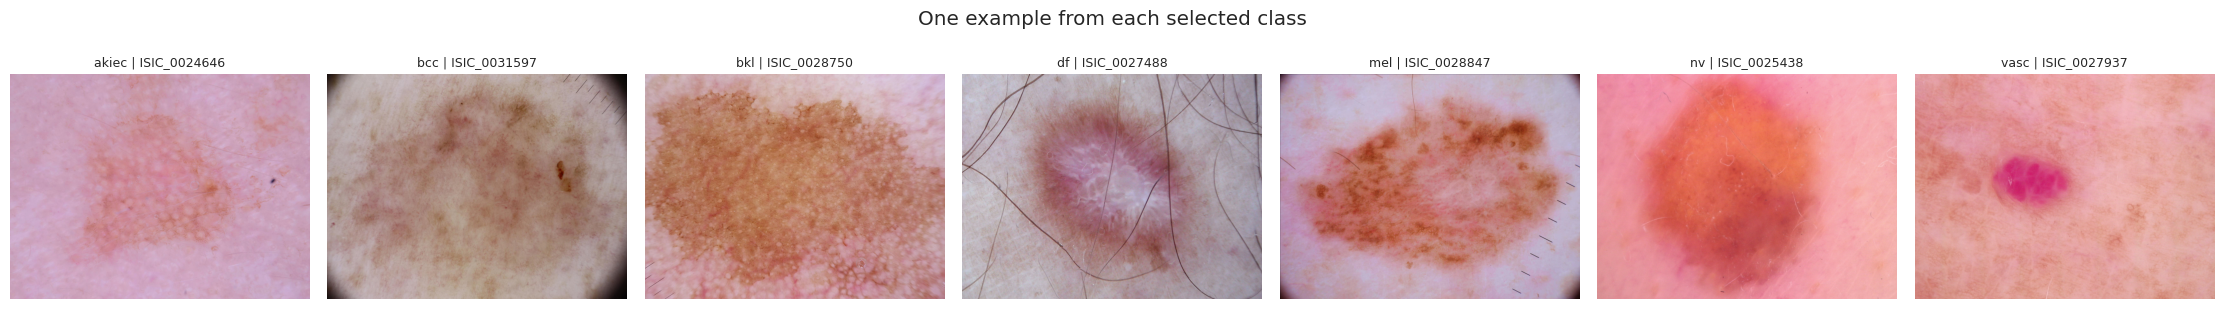

In [61]:
labels = sorted(meta['dx'].unique())
fig, axes = plt.subplots(1, len(labels), figsize=(3.2*len(labels), 3.3), squeeze=False)
for ax, label in zip(axes[0], labels):
    record = meta.loc[meta['dx'].eq(label)].iloc[0]
    bgr = cv2.imread(str(record['path']))
    assert bgr is not None, f'Cannot read image {record["path"]}'
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{label} | {record["image_id"]}', fontsize=9)
    ax.axis('off')
plt.suptitle('One example from each selected class')
plt.tight_layout(); plt.show()

###  Create one safe training/validation/test split

**What this code does:** either reuses a compatible saved split CSV or uses stratified seven-fold grouping by `lesion_id` to get an approximately 70/15/15 split. The program verifies all classes occur in each split and no lesion crosses splits. It writes `lab03_split.csv` so the exact selection can be reused.

**Example:** if two photographs have the same `lesion_id`, putting one in training and one in testing would let a model recognize that lesion rather than generalize to a new one. Grouping prevents that. The new group-aware split is **different from Lab 02's image-level split**, so compare the new raw/filtered/edge scores generated here, never paste old Lab 02 scores into Table 3.

In [62]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

if SPLIT_CSV_PATH:
    existing = pd.read_csv(SPLIT_CSV_PATH)
    assert {'image_id', 'split'}.issubset(existing.columns)
    assert existing['image_id'].is_unique, 'Split CSV has duplicate image_id values.'
    assert set(existing['split'].unique()) <= {'train', 'val', 'test'}
    assert set(existing['image_id']) == set(meta['image_id']), (
        'Saved split CSV must have exactly the same selected image IDs as this run.')
    meta = meta.merge(existing[['image_id','split']], on='image_id', validate='one_to_one')
    print('Reused saved image-level split:', SPLIT_CSV_PATH)
else:
    # 5/7 training, 1/7 validation, 1/7 test (near 70/15/15).
    splitter = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    folds = np.full(len(meta), -1, dtype=np.int16)
    for fold_id, (_, held_indices) in enumerate(
        splitter.split(meta, meta['dx'], groups=meta['lesion_id'])):
        folds[held_indices] = fold_id
    assert (folds >= 0).all()
    meta['split'] = np.where(folds == 0, 'test', np.where(folds == 1, 'val', 'train'))
    print('Created NEW lesion-aware approximate 70/15/15 split; not a verified Lab 01/02 split.')

assert set(meta['split']) == {'train','val','test'}
assert all(meta.loc[meta.split.eq(s), 'dx'].nunique() == len(labels)
           for s in ['train','val','test']), 'At least one class absent from a split: choose a larger subset.'
assert meta.groupby('lesion_id')['split'].nunique().max() == 1, (
    'DATA LEAKAGE: one lesion appears in multiple splits. Fix your saved split CSV.')
meta[['image_id','lesion_id','dx','split']].to_csv(OUTPUT_DIR/'lab03_split.csv', index=False)
print('Saved split:', OUTPUT_DIR/'lab03_split.csv')
display(pd.crosstab(meta['dx'], meta['split'], margins=True))
encoder = LabelEncoder().fit(labels)
meta['y'] = encoder.transform(meta['dx'])

Created NEW lesion-aware approximate 70/15/15 split; not a verified Lab 01/02 split.
Saved split: /content/lab03_outputs/lab03_split.csv


split,test,train,val,All
dx,,,,
akiec,49,237,41,327
bcc,79,353,68,500
bkl,75,350,75,500
df,24,85,6,115
mel,73,342,85,500
nv,68,358,74,500
vasc,20,106,16,142
All,388,1831,365,2584


## Task 1 — Detect edges with five methods

### Load images into RGB and grayscale arrays

**What this code does:** loads the selected images at 224×224, converts RGB into grayscale, and displays both. We use grayscale for the edge algorithms and keep RGB for the raw/filtered model inputs. `uint8` represents integer pixel values 0–255.

**Memory:** storing all raw, filtered and edge images at this size takes over a gigabyte of RAM. If Colab runs low, restart the runtime and use a smaller image size for practice; restore 224×224 for the final matched setup.

Raw array: (2584, 224, 224, 3) uint8 | Grayscale: (2584, 224, 224)
One RGB pixel: [194 149 177] | one grayscale pixel: 166


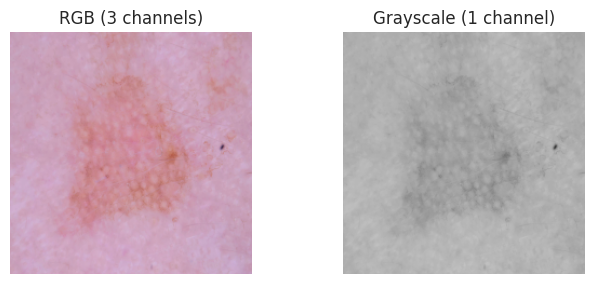

In [63]:
def load_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None: raise FileNotFoundError(path)
    return cv2.cvtColor(cv2.resize(bgr, IMAGE_SIZE, interpolation=cv2.INTER_AREA),
                        cv2.COLOR_BGR2RGB)

X_raw = np.stack([load_rgb(p) for p in meta['path']]).astype(np.uint8)
X_gray = np.stack([cv2.cvtColor(x, cv2.COLOR_RGB2GRAY) for x in X_raw])
y_all = meta['y'].to_numpy()
split_masks = {name: meta['split'].eq(name).to_numpy()
               for name in ['train','val','test']}
print('Raw array:', X_raw.shape, X_raw.dtype, '| Grayscale:', X_gray.shape)
print('One RGB pixel:', X_raw[0,0,0], '| one grayscale pixel:', X_gray[0,0,0])
fig, ax = plt.subplots(1,2, figsize=(7,3))
ax[0].imshow(X_raw[0]); ax[0].set_title('RGB (3 channels)')
ax[1].imshow(X_gray[0], cmap='gray', vmin=0, vmax=255); ax[1].set_title('Grayscale (1 channel)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

###  Define Sobel, Prewitt, Laplacian, LoG and Canny

**What this code does:** creates seven views: Sobel Gx, Sobel Gy, Sobel magnitude, Prewitt, Laplacian, LoG and Canny. `Gx` measures left-to-right brightness change, so it highlights vertical boundaries; `Gy` measures top-to-bottom change, so it highlights horizontal boundaries. Magnitude combines both as `sqrt(Gx² + Gy²)`.

**How the methods differ:** Sobel and Prewitt use **first derivatives** (brightness slopes); Sobel weights the center row/column more. Laplacian uses a **second derivative** (changes in slope) and reacts readily to pixel noise. LoG blurs with a Gaussian before applying Laplacian. Canny blurs, computes gradients, thins candidate edges, applies low/high thresholds, and connects suitable weak edges to strong ones. Here we explicitly apply the Gaussian blur before `cv2.Canny`; OpenCV's `Canny` call itself does **not** automatically perform that blur. Non-Canny outputs are absolute gradient strengths, clipped to 0–255 for consistent display; Canny is a binary 0/255 map.

In [64]:
def uint8_abs(x):
    return np.uint8(np.clip(np.abs(x), 0, 255))

def edge_maps(gray, low=CANNY_LOW, high=CANNY_HIGH, kernel=CANNY_KERNEL):
    assert gray.ndim == 2 and gray.dtype == np.uint8
    assert kernel in (3,5,7) and 0 <= low < high <= 255
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    px = cv2.filter2D(gray, cv2.CV_32F,
                      np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32))
    py = cv2.filter2D(gray, cv2.CV_32F,
                      np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32))
    prewitt = cv2.magnitude(px, py)
    laplacian = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
    log = cv2.Laplacian(cv2.GaussianBlur(gray, (5,5), 0), cv2.CV_32F, ksize=3)
    canny_input = cv2.GaussianBlur(gray, (kernel,kernel), 0)
    canny = cv2.Canny(canny_input, low, high, apertureSize=3, L2gradient=True)
    return {
        'Sobel Gx': uint8_abs(gx),
        'Sobel Gy': uint8_abs(gy),
        'Sobel magnitude': uint8_abs(cv2.magnitude(gx,gy)),
        'Prewitt': uint8_abs(prewitt),
        'Laplacian': uint8_abs(laplacian),
        'LoG': uint8_abs(log),
        'Canny': canny,
    }

sample_index = int(np.flatnonzero(split_masks['train'])[0])
example = edge_maps(X_gray[sample_index])
assert list(example) == ['Sobel Gx','Sobel Gy','Sobel magnitude','Prewitt',
                         'Laplacian','LoG','Canny']
assert all(im.shape == X_gray[sample_index].shape and im.dtype == np.uint8
           for im in example.values())
print('All 7 edge outputs generated successfully. Shapes and dtypes validated.')

All 7 edge outputs generated successfully. Shapes and dtypes validated.


### Show all methods for three different classes

**What this code does:** selects representative images from **three training classes** and makes the handout's six-column original → Sobel → Prewitt → Laplacian → LoG → Canny figure. A second figure displays Sobel Gx versus Gy.

**What to look for:** continuous lesion boundaries, thin/sharp edges, noise or hair mistaken for lesion edges, and broken contours. An edge map may emphasize features *inside* the lesion as well as its outer border. Save observations for Table 1.

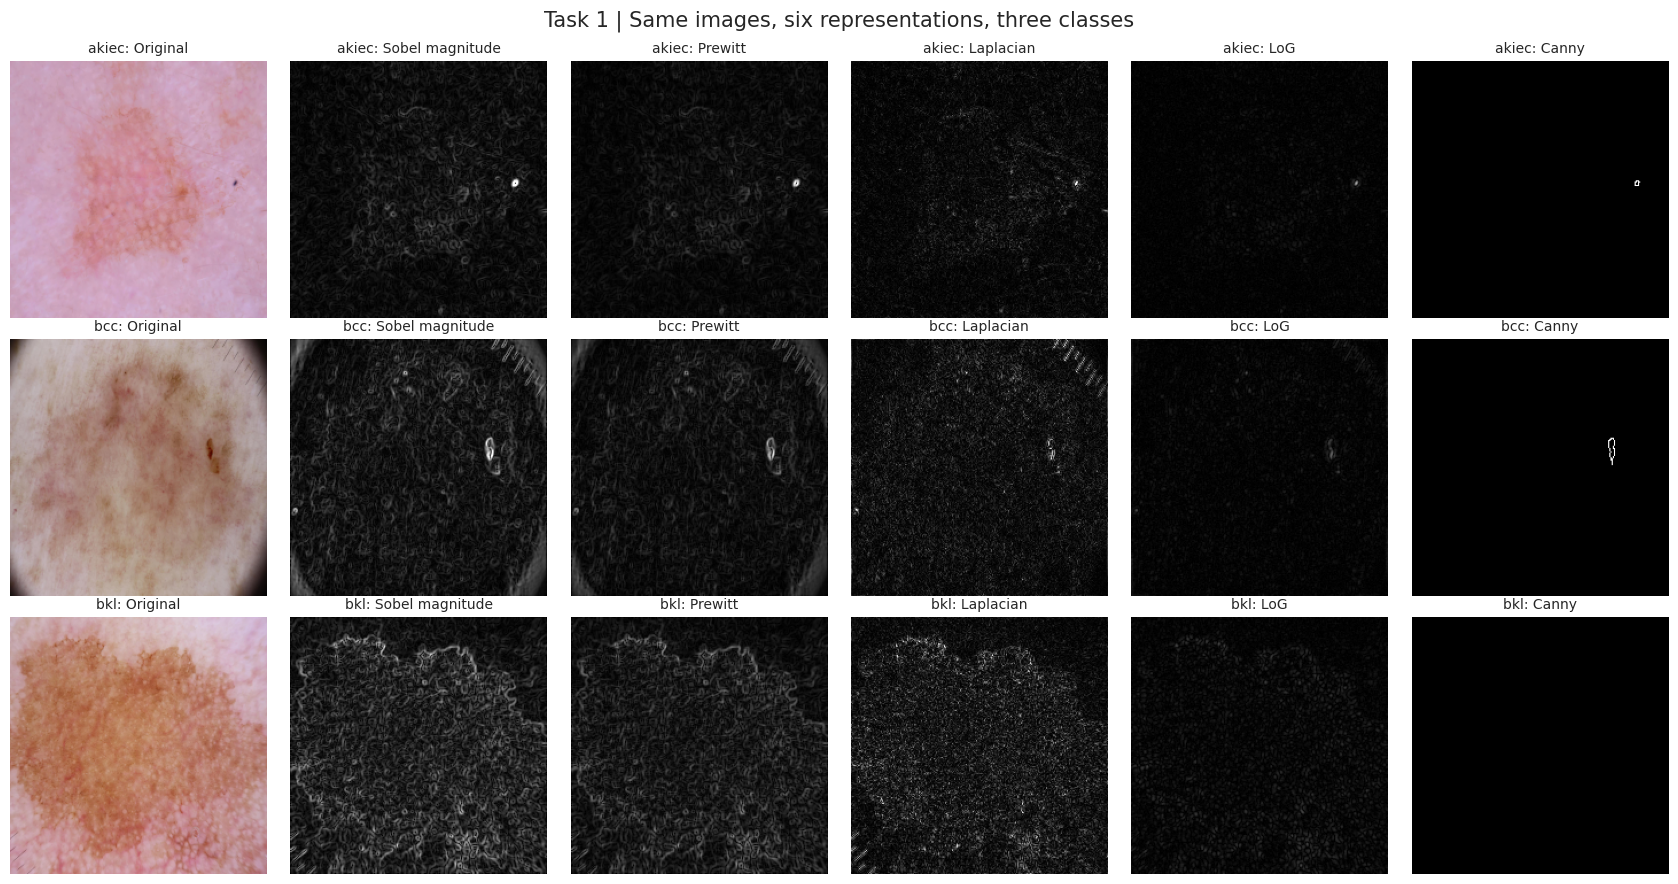

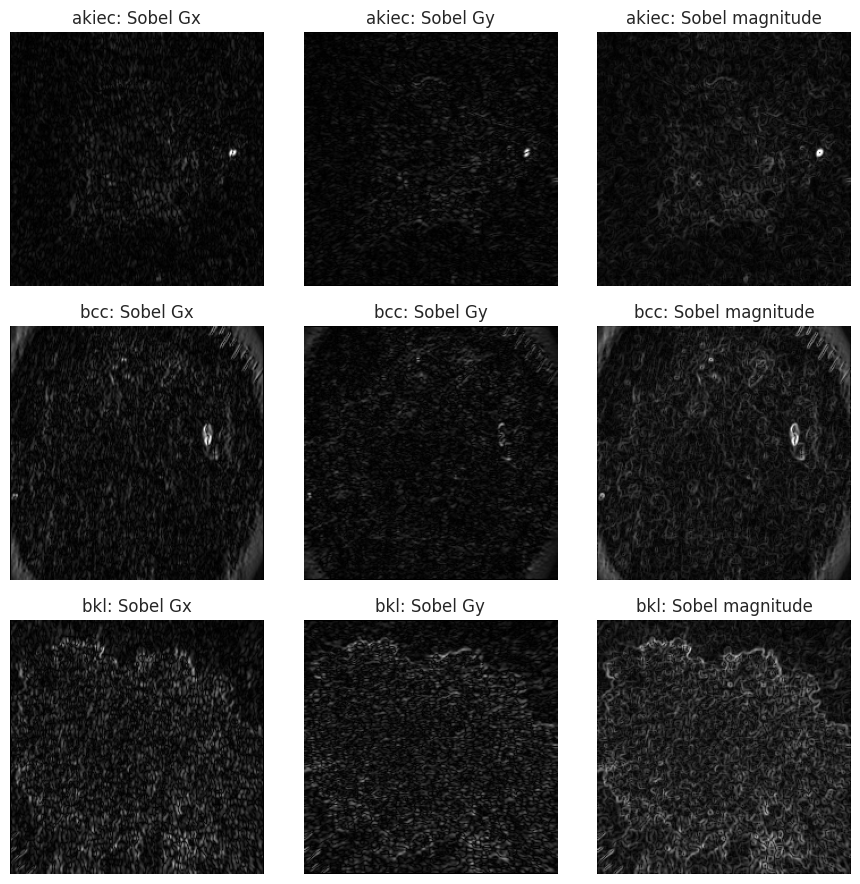

In [65]:
assert len(labels) >= 3, 'The handout requires at least three different classes.'
representatives = [int(meta.index[(meta['dx'].eq(label)) & (meta['split'].eq('train'))][0])
                   for label in labels[:3]]
columns = ['Original', 'Sobel magnitude', 'Prewitt', 'Laplacian', 'LoG', 'Canny']
fig, axes = plt.subplots(3, len(columns), figsize=(17,9))
for row, idx in enumerate(representatives):
    maps = edge_maps(X_gray[idx])
    for col, title in enumerate(columns):
        axes[row,col].imshow(X_raw[idx] if title == 'Original' else maps[title],
                             cmap=None if title == 'Original' else 'gray',
                             vmin=None if title == 'Original' else 0,
                             vmax=None if title == 'Original' else 255)
        axes[row,col].set_title(f'{labels[y_all[idx]]}: {title}', fontsize=10)
        axes[row,col].axis('off')
fig.suptitle('Task 1 | Same images, six representations, three classes', fontsize=15)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'task1_required_comparison.png',dpi=180,bbox_inches='tight'); plt.show()
fig, axes = plt.subplots(3,3,figsize=(9,9))
for row,idx in enumerate(representatives):
    maps=edge_maps(X_gray[idx])
    for col,name in enumerate(['Sobel Gx','Sobel Gy','Sobel magnitude']):
        axes[row,col].imshow(maps[name],cmap='gray',vmin=0,vmax=255)
        axes[row,col].set_title(f'{labels[y_all[idx]]}: {name}')
        axes[row,col].axis('off')
plt.tight_layout(); plt.show()

## Task 2 — Investigate noise and smoothing

###  Add two types of noise, then try two filters

**What this code does:** adds Gaussian noise (small random value changes across many pixels) and salt-and-pepper noise (some pixels become black or white). Gaussian filtering averages nearby pixels using distance weights. Median filtering replaces a pixel by the median of its neighborhood, often removing isolated black/white impulses more effectively.

**Example:** for values `[98, 100, 101, 102, 255]`, the median is 101 while the mean is 131.2, so median is less affected by one extreme white pixel. Too much smoothing can erase real thin lesion details.

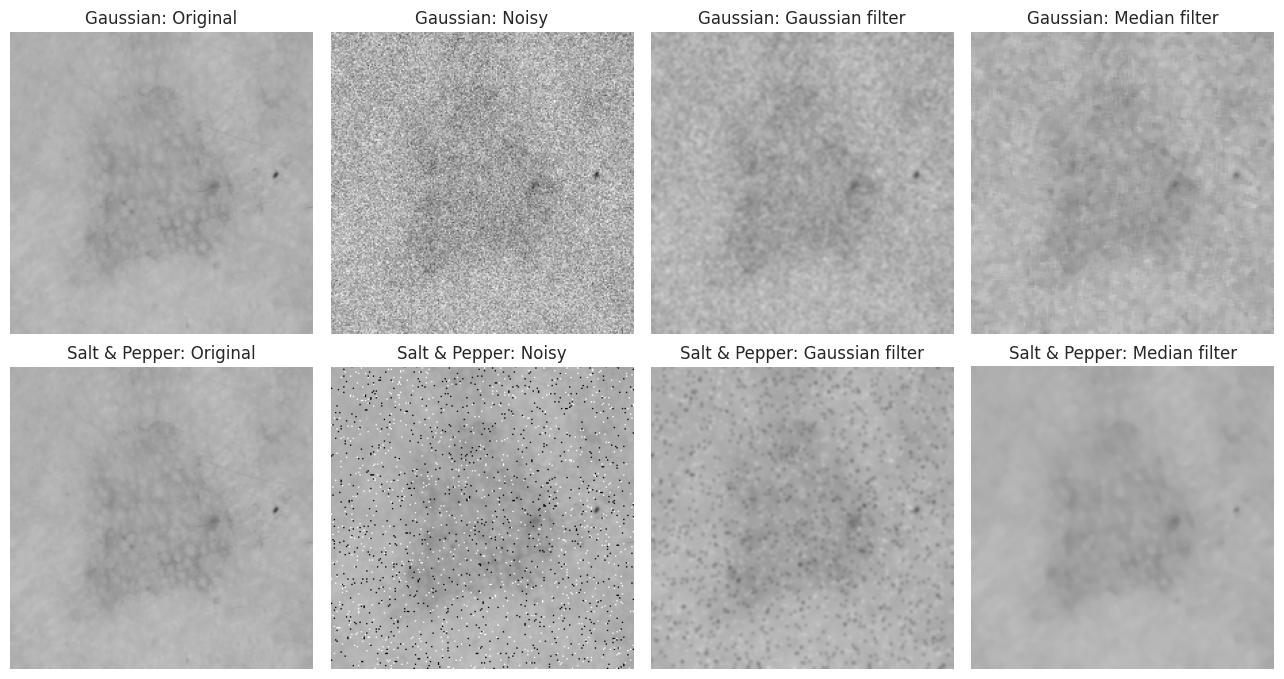

In [66]:
def gaussian_noise(gray, sigma=25, seed=SEED):
    noise_rng = np.random.default_rng(seed)
    return np.uint8(np.clip(gray.astype(np.float32) +
                            noise_rng.normal(0, sigma, gray.shape), 0, 255))

def salt_pepper_noise(gray, fraction=.04, seed=SEED+1):
    noise_rng = np.random.default_rng(seed)
    out = gray.copy()
    values = noise_rng.random(gray.shape)
    out[values < fraction/2] = 0
    out[(values >= fraction/2) & (values < fraction)] = 255
    return out

def filtering(gray, name):
    if name == 'gaussian': return cv2.GaussianBlur(gray, (5,5), 0)
    if name == 'median':   return cv2.medianBlur(gray, 5)
    if name == 'mean':     return cv2.blur(gray, (5,5))
    if name == 'sharpen':
        k = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
        return cv2.filter2D(gray, -1, k)
    raise ValueError(f'Unknown filter: {name}')

clean = X_gray[representatives[0]]
noise_inputs = {'Gaussian': gaussian_noise(clean),
                'Salt & Pepper': salt_pepper_noise(clean)}
fig, axes = plt.subplots(2, 4, figsize=(13,7))
for row, (noise_name, noisy) in enumerate(noise_inputs.items()):
    variants = [('Original',clean),('Noisy',noisy),
                ('Gaussian filter', filtering(noisy,'gaussian')),
                ('Median filter', filtering(noisy,'median'))]
    for col, (name, im) in enumerate(variants):
        axes[row,col].imshow(im,cmap='gray',vmin=0,vmax=255)
        axes[row,col].set_title(f'{noise_name}: {name}')
        axes[row,col].axis('off')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'task2_noise_and_filters.png',dpi=180,bbox_inches='tight'); plt.show()

###  Compare how each detector handles each noise type

**What this code does:** plots edge maps from the original image, the noisy image, and both filtered versions. It makes one grid for Gaussian noise and another for salt-and-pepper noise. **Compare within a row**: if noise creates many isolated white lines, that detector is sensitive under this condition. Then compare whether filtering removes false edges while keeping true boundaries.

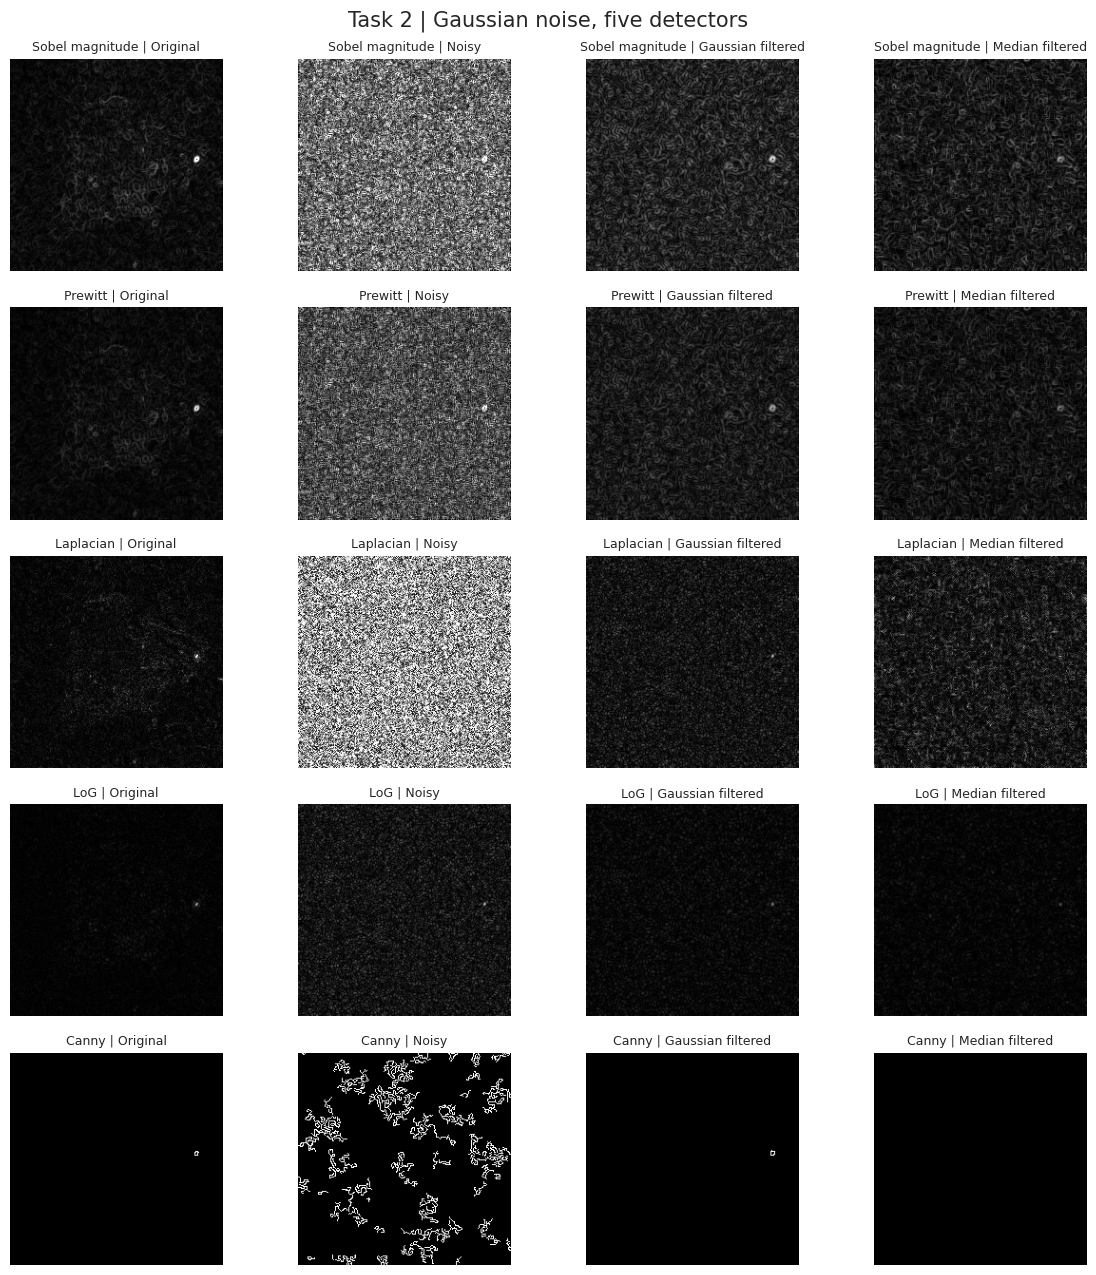

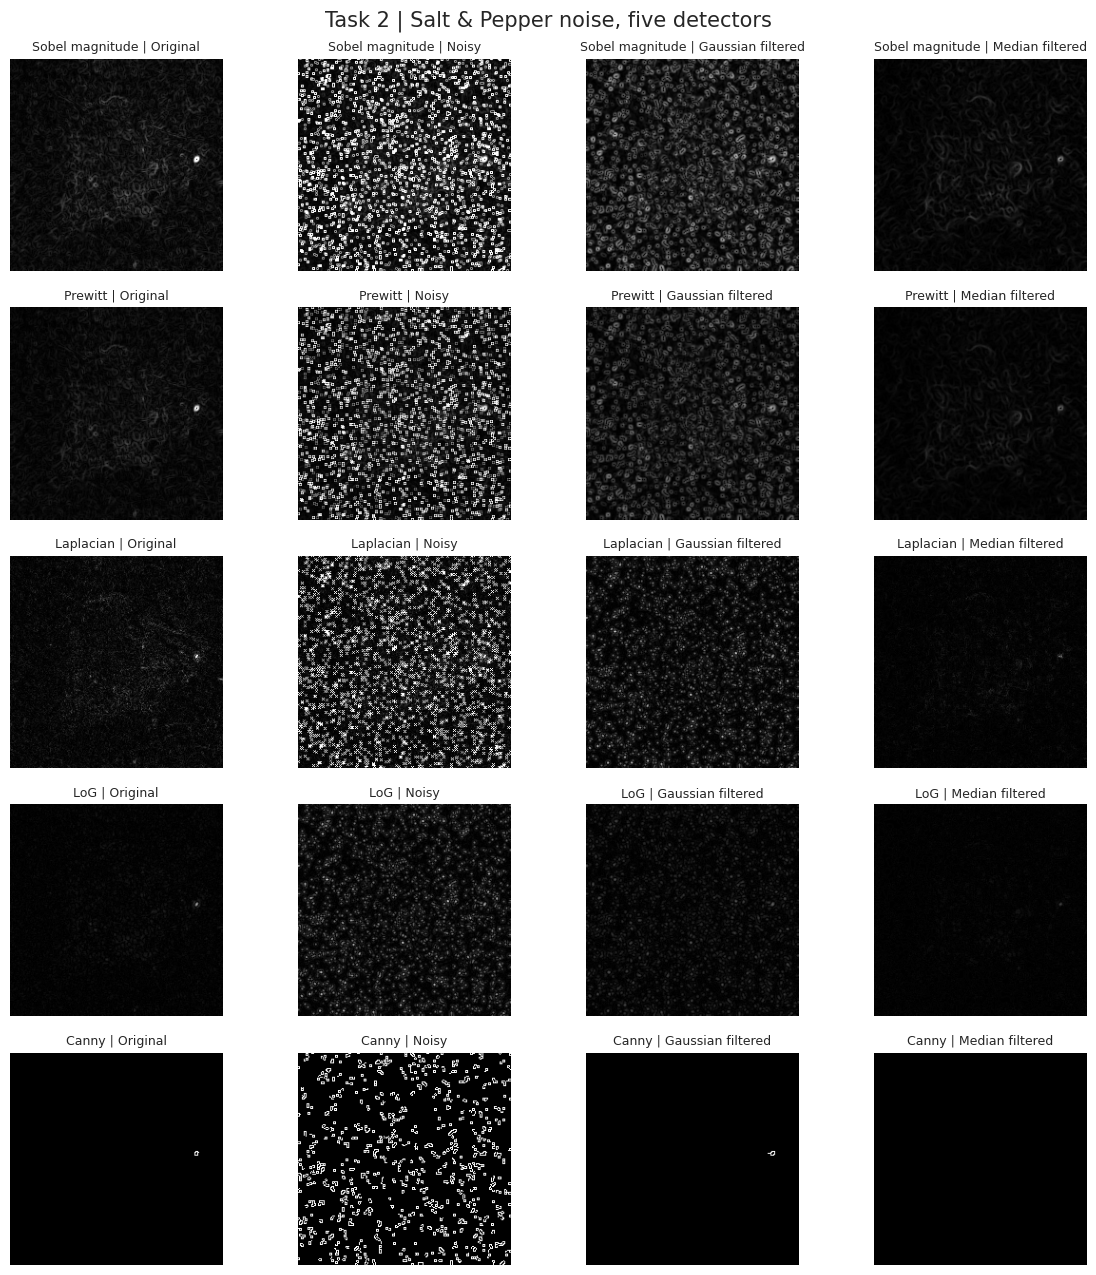

In [67]:
DETECTORS=['Sobel magnitude','Prewitt','Laplacian','LoG','Canny']
for noise_name,noisy in noise_inputs.items():
    variants={'Original':clean, 'Noisy':noisy,
              'Gaussian filtered':filtering(noisy,'gaussian'),
              'Median filtered':filtering(noisy,'median')}
    fig,axes=plt.subplots(len(DETECTORS),len(variants),figsize=(12,13))
    for r,method in enumerate(DETECTORS):
        for c,(variant,im) in enumerate(variants.items()):
            axes[r,c].imshow(edge_maps(im)[method],cmap='gray',vmin=0,vmax=255)
            axes[r,c].set_title(f'{method} | {variant}',fontsize=9)
            axes[r,c].axis('off')
    fig.suptitle(f'Task 2 | {noise_name} noise, five detectors',fontsize=15)
    plt.tight_layout()
    safe=noise_name.lower().replace(' ','_').replace('&','and')
    plt.savefig(OUTPUT_DIR/f'task2_{safe}_edge_maps.png',dpi=150,bbox_inches='tight')
    plt.show()

###  Build Table 1 with measured proxies and your observations

**What this code does:** repeats the selected Table 1 cases for all **three training-class examples**. It measures agreement between each noisy/filtered edge map and the same detector's *clean* map. It also counts extra and missing edge pixels. These are reproducible **proxies, not ground-truth boundary quality**: a clean map may already contain irrelevant edges.

**Your part:** after inspecting the plots, replace “Add your visual assessment” in `Edge quality` with a short observation such as “main border stays connected; hair produces false lines.” The numerical columns help support that judgment but cannot decide whether an edge is clinically useful.

In [68]:
from sklearn.metrics import f1_score

TABLE1_CASES = [
    ('Sobel magnitude','Original','None','None'),
    ('Sobel magnitude','Noisy','Gaussian','None'),
    ('Sobel magnitude','Noisy','Salt & Pepper','None'),
    ('Sobel magnitude','Noisy','Gaussian','Gaussian filter'),
    ('Sobel magnitude','Noisy','Salt & Pepper','Median filter'),
    ('Prewitt','Original','None','None'),
    ('Laplacian','Original','None','None'),
    ('LoG','Noisy','Gaussian','Gaussian filter'),
    ('Canny','Original','None','Explicit Gaussian blur'),
    ('Canny','Noisy','Gaussian','Gaussian filter + Canny blur'),
    ('Canny','Noisy','Salt & Pepper','Median filter + Canny blur'),
]
def binary_edges(im,method):
    return im > 0 if method == 'Canny' else im >= 50

rows=[]
for method,input_type,noise_type,prep in TABLE1_CASES:
    scores, extra, missing = [], [], []
    for j, idx in enumerate(representatives):
        baseline = X_gray[idx]
        source = baseline if noise_type == 'None' else (
            gaussian_noise(baseline,seed=SEED+j) if noise_type == 'Gaussian'
            else salt_pepper_noise(baseline,seed=SEED+1+j))
        if 'Gaussian filter' in prep: source = filtering(source,'gaussian')
        if 'Median filter' in prep: source = filtering(source,'median')
        detected = binary_edges(edge_maps(source)[method],method)
        reference = binary_edges(edge_maps(baseline)[method],method)
        scores.append(f1_score(reference.ravel(),detected.ravel(),zero_division=0))
        extra.append(np.logical_and(detected,~reference).mean()*100)
        missing.append(np.logical_and(reference,~detected).mean()*100)
    rows.append({'Edge Detector':method,'Input Image':input_type,
                 'Noise Type':noise_type,'Preprocessing':prep,
                 'Edge quality':'Add your visual assessment',
                 'Noise sensitivity':f'{100*(1-np.mean(scores)):.1f}% difference proxy',
                 'Observations':f'Average across 3 classes: extra {np.mean(extra):.1f}%; '
                                f'missing {np.mean(missing):.1f}%; '
                                f'clean-map agreement F1 {np.mean(scores):.3f}'})
table1 = pd.DataFrame(rows)
display(table1)
table1.to_csv(OUTPUT_DIR/'table1_noise_preprocessing.csv',index=False)

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge quality,Noise sensitivity,Observations
0,Sobel magnitude,Original,None,None,Add your visual assessment,0.0% difference proxy,Average across 3 classes: extra 0.0%; missing ...
1,Sobel magnitude,Noisy,Gaussian,None,Add your visual assessment,79.9% difference proxy,Average across 3 classes: extra 74.8%; missing...
2,Sobel magnitude,Noisy,Salt & Pepper,None,Add your visual assessment,58.2% difference proxy,Average across 3 classes: extra 23.7%; missing...
3,Sobel magnitude,Noisy,Gaussian,Gaussian filter,Add your visual assessment,73.3% difference proxy,Average across 3 classes: extra 21.6%; missing...
4,Sobel magnitude,Noisy,Salt & Pepper,Median filter,Add your visual assessment,64.0% difference proxy,Average across 3 classes: extra 0.2%; missing ...
5,Prewitt,Original,None,None,Add your visual assessment,0.0% difference proxy,Average across 3 classes: extra 0.0%; missing ...
6,Laplacian,Original,None,None,Add your visual assessment,0.0% difference proxy,Average across 3 classes: extra 0.0%; missing ...
7,LoG,Noisy,Gaussian,Gaussian filter,Add your visual assessment,64.4% difference proxy,Average across 3 classes: extra 0.0%; missing ...
8,Canny,Original,None,Explicit Gaussian blur,Add your visual assessment,33.3% difference proxy,Average across 3 classes: extra 0.0%; missing ...
9,Canny,Noisy,Gaussian,Gaussian filter + Canny blur,Add your visual assessment,52.8% difference proxy,Average across 3 classes: extra 0.0%; missing ...


## Task 3 — Choose Canny thresholds and smoothing

###  Compare three threshold pairs and a larger kernel

**What this code does:** tries the handout's `(30,100)`, `(50,150)`, `(100,200)` threshold pairs with a 3×3 Gaussian, then `(50,150)` with a 5×5 Gaussian. It plots results for **three training classes** and reports the *average count of white edge pixels*, a clear definition of “number of detected edges.” A count of connected components is only a rough continuity proxy.

**Concept:** pixels stronger than the high threshold seed strong edges; pixels above the low threshold survive when connected to strong edges. Higher thresholds often remove faint lines (possibly both noise and real structure); wider smoothing can suppress texture or thin borders. Inspect your actual figures rather than assuming a particular setting is best.

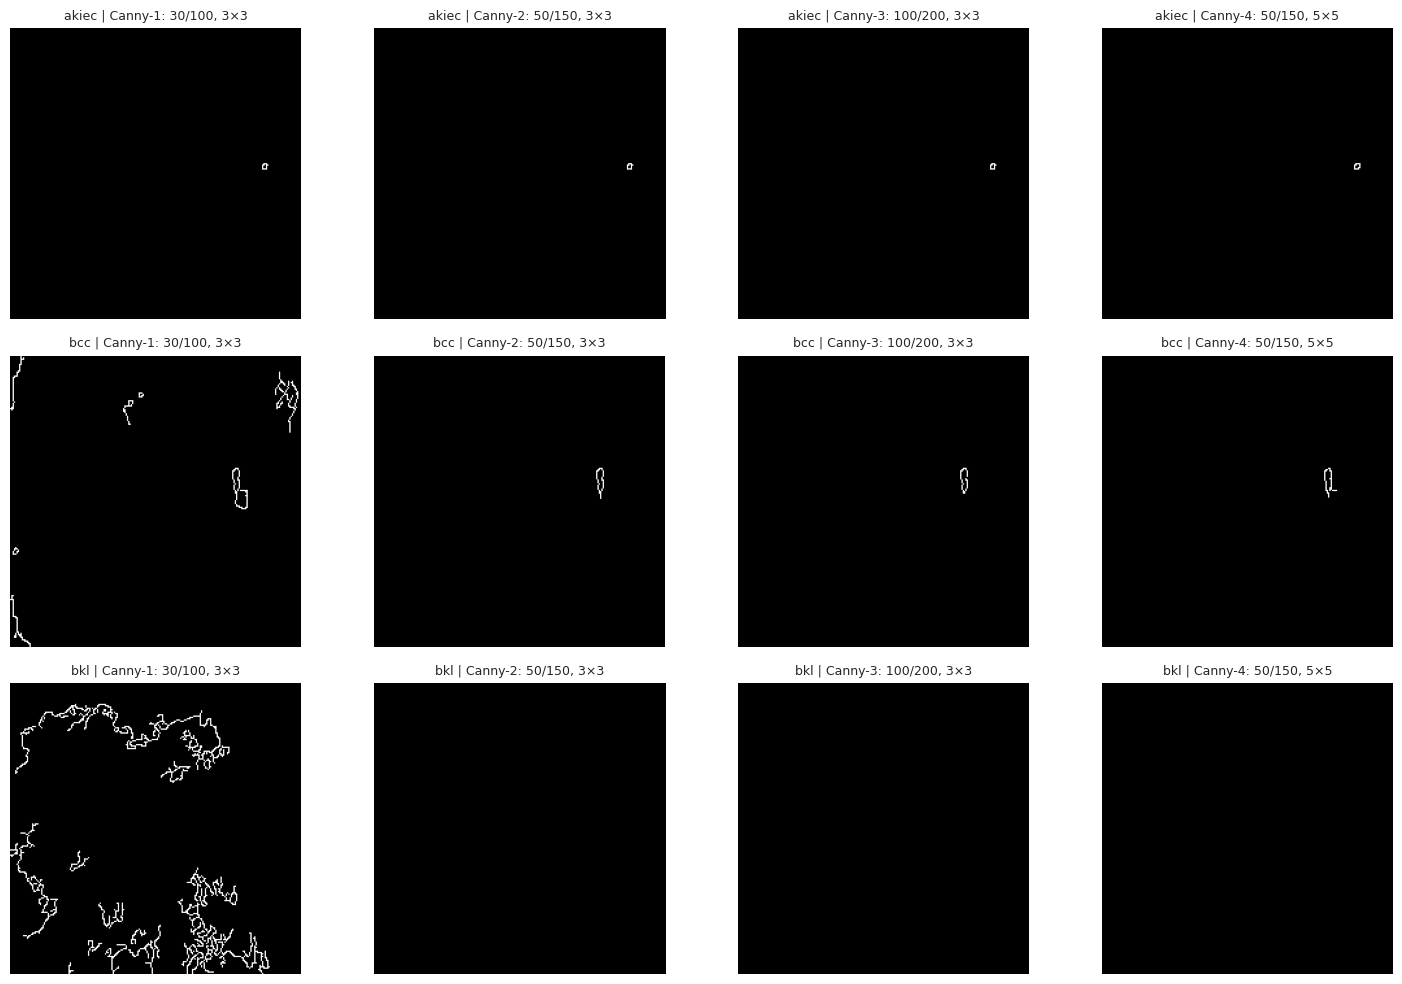

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges (mean edge pixels),Observation
0,Canny-1,30,100,3×3,Add your visual assessment,854.3,Mean connected components: 10.3 (proxy)
1,Canny-2,50,150,3×3,Add your visual assessment,21.0,Mean connected components: 0.7 (proxy)
2,Canny-3,100,200,3×3,Add your visual assessment,19.3,Mean connected components: 0.7 (proxy)
3,Canny-4,50,150,5×5,Add your visual assessment,23.0,Mean connected components: 0.7 (proxy)


In [69]:
CANNY_CONFIGS = [('Canny-1',30,100,3),('Canny-2',50,150,3),
                 ('Canny-3',100,200,3),('Canny-4',50,150,5)]
fig, axes = plt.subplots(len(representatives),len(CANNY_CONFIGS),figsize=(15,10))
table2_rows=[]
for col,(name,low,high,kernel) in enumerate(CANNY_CONFIGS):
    pixels,components=[],[]
    for row,idx in enumerate(representatives):
        emap=edge_maps(X_gray[idx],low,high,kernel)['Canny']
        pixels.append(int(np.count_nonzero(emap)))
        n_components,_=cv2.connectedComponents((emap>0).astype(np.uint8),connectivity=8)
        components.append(n_components-1)
        ax=axes[row,col]
        ax.imshow(emap,cmap='gray',vmin=0,vmax=255)
        ax.set_title(f'{labels[y_all[idx]]} | {name}: {low}/{high}, {kernel}×{kernel}',fontsize=9)
        ax.axis('off')
    table2_rows.append({'Configuration':name,'Low Threshold':low,'High Threshold':high,
                        'Kernel Size':f'{kernel}×{kernel}',
                        'Edge Quality':'Add your visual assessment',
                        'Number of Detected Edges (mean edge pixels)':round(float(np.mean(pixels)),1),
                        'Observation':f'Mean connected components: {np.mean(components):.1f} (proxy)'})
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'task3_canny_settings.png',dpi=180,bbox_inches='tight'); plt.show()
table2=pd.DataFrame(table2_rows)
display(table2)
table2.to_csv(OUTPUT_DIR/'table2_canny_parameters.csv',index=False)

###  Record your edge choice using the training images

**What this code does:** sets the one edge representation that will be applied to *every* image for classification. The default Canny 50/150, 3×3 is an **example**, not a proven winner. Look at Tasks 1–3 and Table 2 and edit the method/settings and reason. Do **not** use test accuracy to choose the settings; that would give the test set influence over the experiment.

In [70]:
BEST_EDGE_METHOD = 'Canny'    # 'Sobel magnitude', 'Prewitt', 'Laplacian', 'LoG', 'Canny'
BEST_CANNY_LOW = 50           # CHANGE after inspecting Table 2 if your choice differs
BEST_CANNY_HIGH = 150
BEST_CANNY_KERNEL = 3
EDGE_SELECTION_REASON = 'Example: fairly continuous boundaries with manageable background responses.'
assert BEST_EDGE_METHOD in DETECTORS
assert 0 <= BEST_CANNY_LOW < BEST_CANNY_HIGH <= 255
assert BEST_CANNY_KERNEL in (3,5,7)
print('Chosen edge representation:',BEST_EDGE_METHOD,
      '| Canny settings:',(BEST_CANNY_LOW,BEST_CANNY_HIGH,BEST_CANNY_KERNEL))
print('Record/modify your reason:',EDGE_SELECTION_REASON)

Chosen edge representation: Canny | Canny settings: (50, 150, 3)
Record/modify your reason: Example: fairly continuous boundaries with manageable background responses.


## Task 4 — Make the three matched image datasets

### Raw RGB, Lab 02 filtered RGB, and edge maps

**What this code does:** creates three arrays from the same ordered 2,584 selected images: A = raw RGB, B = your chosen Lab 02-style filter, C = the chosen grayscale edges repeated in three channels. Repeating channels satisfies a three-channel CNN input but **does not recover any removed color**. Filter and edge conversion happen in the same way for training, validation, and test images.

**Fairness detail:** models will use the same labels and indices for each array, and each run starts fresh. The classic models use 32×32 grayscale features for all three versions; CNNs use 224×224 three-channel arrays for all three.

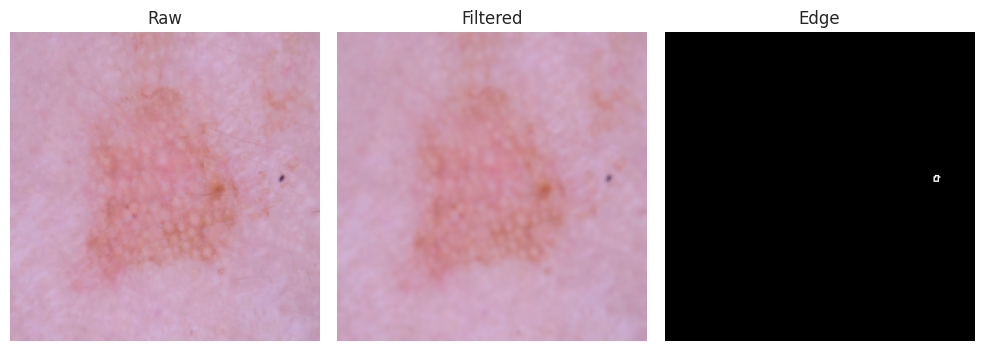

Identical image ID order, labels, and split indices across all three sets.


In [71]:
def filter_rgb(rgb,method):
    if method=='gaussian': return cv2.GaussianBlur(rgb,(5,5),0)
    if method=='median':   return cv2.medianBlur(rgb,5)
    if method=='mean':     return cv2.blur(rgb,(5,5))
    if method=='sharpen':
        k=np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],dtype=np.float32)
        return cv2.filter2D(rgb,-1,k)
    raise ValueError(method)

def chosen_edge(rgb):
    gray=cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)
    e=edge_maps(gray,BEST_CANNY_LOW,BEST_CANNY_HIGH,BEST_CANNY_KERNEL)[BEST_EDGE_METHOD]
    return np.repeat(e[:,:,None],3,axis=2)

X_filtered=np.stack([filter_rgb(x,LAB02_FILTER) for x in X_raw]).astype(np.uint8)
X_edge=np.stack([chosen_edge(x) for x in X_raw]).astype(np.uint8)
versions={'Raw':X_raw,'Filtered':X_filtered,'Edge':X_edge}
assert all(x.shape==X_raw.shape and x.dtype==np.uint8 for x in versions.values())
fig,ax=plt.subplots(1,3,figsize=(10,3.5))
for a,(name,data) in zip(ax,versions.items()):
    a.imshow(data[sample_index]);a.set_title(name);a.axis('off')
plt.tight_layout();plt.savefig(OUTPUT_DIR/'task4_three_representations.png',dpi=180,bbox_inches='tight');plt.show()
print('Identical image ID order, labels, and split indices across all three sets.')

###  Check that the data are aligned

**What this code does:** prints class counts by split and verifies image array shapes. This is an experimental sanity check: all three representations must correspond to exactly the same ordered image IDs. A smaller class can be hidden by overall accuracy, so we later report **macro** precision, recall and F1 as well.

In [72]:
for s,mask in split_masks.items():
    print(f'{s:5s}: {mask.sum():5d} images | class counts:',
          dict(zip(*np.unique(y_all[mask],return_counts=True))))
print('Representations:',{key:data.shape for key,data in versions.items()})
print('Label names:',list(encoder.classes_))

train:  1831 images | class counts: {np.int64(0): np.int64(237), np.int64(1): np.int64(353), np.int64(2): np.int64(350), np.int64(3): np.int64(85), np.int64(4): np.int64(342), np.int64(5): np.int64(358), np.int64(6): np.int64(106)}
val  :   365 images | class counts: {np.int64(0): np.int64(41), np.int64(1): np.int64(68), np.int64(2): np.int64(75), np.int64(3): np.int64(6), np.int64(4): np.int64(85), np.int64(5): np.int64(74), np.int64(6): np.int64(16)}
test :   388 images | class counts: {np.int64(0): np.int64(49), np.int64(1): np.int64(79), np.int64(2): np.int64(75), np.int64(3): np.int64(24), np.int64(4): np.int64(73), np.int64(5): np.int64(68), np.int64(6): np.int64(20)}
Representations: {'Raw': (2584, 224, 224, 3), 'Filtered': (2584, 224, 224, 3), 'Edge': (2584, 224, 224, 3)}
Label names: [np.str_('akiec'), np.str_('bcc'), np.str_('bkl'), np.str_('df'), np.str_('mel'), np.str_('nv'), np.str_('vasc')]


## Task 5 — Train and evaluate the models

###  Define accuracy, macro precision, recall, F1 and timing

**What this code does:** computes test scores for every run. **Accuracy** = correctly labeled images / all images. For a particular class, **precision** = correct positive predictions / all positive predictions; **recall** = correct positive predictions / all actual members. **F1** is their harmonic mean. Macro precision/recall/F1 average all seven classes equally (useful when some classes have fewer images).

**Timing:** training seconds cover fitting, and inference milliseconds/image cover prediction of the test set. These timings depend on your Colab hardware and do not include image loading or edge-map generation. The validation macro F1 is stored separately for selecting the model in Task 6.

In [73]:
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

results=[]
predictions={}
train_histories={}

def compute_metrics(y_true,pred):
    p,r,f,_=precision_recall_fscore_support(
        y_true,pred,labels=np.arange(len(labels)),average='macro',zero_division=0)
    return dict(Accuracy=accuracy_score(y_true,pred),Precision=p,Recall=r,F1=f)

def store_result(model_name,version,validation_prediction,test_prediction,train_seconds,infer_seconds):
    val=compute_metrics(y_all[split_masks['val']],validation_prediction)
    test=compute_metrics(y_all[split_masks['test']],test_prediction)
    row={'Model':model_name,'Representation':version,
         'Validation F1':val['F1'],**test,
         'Training Time (s)':train_seconds,
         'Inference Time (ms/image)':1000*infer_seconds/int(split_masks['test'].sum())}
    results.append(row)
    predictions[(model_name,version)] = np.asarray(test_prediction)
    return row

print('Metrics prepared. Macro precision/recall/F1 treats all selected classes equally.')

Metrics prepared. Macro precision/recall/F1 treats all selected classes equally.


### Train SVM, Random Forest and KNN on all three inputs

**What this code does:** resizes each version to 32×32 grayscale, flattens it into 1,024 numbers, and trains three classical classifiers separately on raw, filtered, and edge images: **9 runs**. SVM tries to separate classes; Random Forest votes across trees; KNN predicts from nearby training examples. SVM scaling is fitted on training images only.

**Why flatten?** These three models accept a vector of features, while a CNN can learn directly from a grid. Downscaling keeps the classical runs practical but loses detail; the resulting comparison concerns these specific models and settings.

In [74]:
def classical_features(images):
    small=np.stack([cv2.resize(cv2.cvtColor(im,cv2.COLOR_RGB2GRAY),
                               CLASSICAL_SIZE,interpolation=cv2.INTER_AREA)
                    for im in images])
    return small.reshape(len(images),-1).astype(np.float32)/255.0

for version,images in versions.items():
    feature_matrix=classical_features(images)
    xtr,xval,xtest=[feature_matrix[split_masks[s]] for s in ('train','val','test')]
    ytr=y_all[split_masks['train']]
    models={
        'SVM':make_pipeline(StandardScaler(),SVC(C=2.0,kernel='rbf',class_weight='balanced')),
        'Random Forest':RandomForestClassifier(n_estimators=120,min_samples_leaf=2,
                                               class_weight='balanced_subsample',n_jobs=-1,
                                               random_state=SEED),
        'KNN':make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=5,n_jobs=-1))
    }
    for model_name,model in models.items():
        tic=time.perf_counter();model.fit(xtr,ytr);training=time.perf_counter()-tic
        val_pred=model.predict(xval)
        tic=time.perf_counter();test_pred=model.predict(xtest);inference=time.perf_counter()-tic
        result=store_result(model_name,version,val_pred,test_pred,training,inference)
        print(f'{model_name:14s} {version:8s} test accuracy={result["Accuracy"]:.3f} '
              f'macro F1={result["F1"]:.3f} | train {training:.1f}s')
    del feature_matrix,xtr,xval,xtest,models
    gc.collect()

display(pd.DataFrame(results).round(4))

SVM            Raw      test accuracy=0.420 macro F1=0.391 | train 1.8s
Random Forest  Raw      test accuracy=0.415 macro F1=0.343 | train 3.5s
KNN            Raw      test accuracy=0.348 macro F1=0.283 | train 0.0s
SVM            Filtered test accuracy=0.415 macro F1=0.387 | train 2.0s
Random Forest  Filtered test accuracy=0.407 macro F1=0.338 | train 3.4s
KNN            Filtered test accuracy=0.348 macro F1=0.282 | train 0.0s
SVM            Edge     test accuracy=0.214 macro F1=0.165 | train 2.3s
Random Forest  Edge     test accuracy=0.253 macro F1=0.192 | train 1.5s
KNN            Edge     test accuracy=0.152 macro F1=0.113 | train 0.0s


,Model,Representation,Validation F1,Accuracy,Precision,Recall,F1,Training Time (s),Inference Time (ms/image)
0,SVM,Raw,0.2935,0.4201,0.3907,0.4007,0.3910,1.7875,1.4026
1,Random Forest,Raw,0.3114,0.4149,0.3884,0.3445,0.3430,3.4513,0.1154
2,KNN,Raw,0.2426,0.3479,0.3025,0.2896,0.2828,0.0245,0.1439
3,SVM,Filtered,0.2893,0.4149,0.3870,0.3970,0.3869,1.9767,1.3912
4,Random Forest,Filtered,0.3276,0.4072,0.3911,0.3382,0.3377,3.3854,0.1131
5,KNN,Filtered,0.2408,0.3479,0.3024,0.2894,0.2817,0.0191,0.1030
6,SVM,Edge,0.1869,0.2139,0.2006,0.1849,0.1653,2.2578,1.3275
7,Random Forest,Edge,0.2174,0.2526,0.2054,0.2167,0.1918,1.5135,0.1561
8,KNN,Edge,0.1197,0.1521,0.1534,0.1424,0.1132,0.0287,0.1691


###  Build two convolutional neural networks

**What this code does:** CNN Model 1 learns kernels from scratch. CNN Model 2 uses a pretrained MobileNetV2 as a **frozen** visual feature extractor and trains a new classification head. The second model receives pixels in the required `[-1,1]` range. For each image type, both networks have the same architecture and eight training epochs.

**Step by step:** a convolution learns small visual patterns; ReLU lets the network combine patterns nonlinearly; pooling reduces resolution; a final dense/softmax layer gives one probability per class. **Cross-entropy** penalizes wrong probabilities; **backpropagation** and Adam adjust weights during training. `class_weight` gives rare classes more influence. A validation curve that worsens while training keeps improving may indicate **overfitting**.

MobileNetV2 pretrained weights download the first time. If your Colab runtime lacks TensorFlow, run `%pip install tensorflow` in a **separate Colab cell**, restart the runtime, then rerun from the top. The models in this notebook differ from the architectures in your earlier Lab 02 notebook, so old accuracies are not directly matched.

In [75]:
try:
    import tensorflow as tf
except ImportError as exc:
    raise ImportError('TensorFlow is required for the CNN cells. In Colab install it '
                      'with %pip install tensorflow, then restart the runtime.') from exc

from sklearn.utils.class_weight import compute_class_weight
class_weights=dict(enumerate(compute_class_weight(
    'balanced',classes=np.arange(len(labels)),y=y_all[split_masks['train']])))
print('TensorFlow:',tf.__version__,'| GPUs:',tf.config.list_physical_devices('GPU'))
print('Training class weights:',{labels[k]:round(v,2) for k,v in class_weights.items()})

def build_cnn1():
    inputs=tf.keras.Input(shape=(IMAGE_SIZE[1],IMAGE_SIZE[0],3))
    x=tf.keras.layers.Rescaling(1/255)(inputs)
    for width in (32,64,128):
        x=tf.keras.layers.Conv2D(width,3,padding='same',activation='relu')(x)
        x=tf.keras.layers.MaxPooling2D(2)(x)
    x=tf.keras.layers.GlobalAveragePooling2D()(x)
    x=tf.keras.layers.Dense(64,activation='relu')(x)
    outputs=tf.keras.layers.Dense(len(labels),activation='softmax')(x)
    model=tf.keras.Model(inputs,outputs,name='CNN_1_from_scratch')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

def build_cnn2():
    inputs=tf.keras.Input(shape=(IMAGE_SIZE[1],IMAGE_SIZE[0],3))
    x=tf.keras.layers.Rescaling(scale=1/127.5,offset=-1)(inputs)
    base=tf.keras.applications.MobileNetV2(input_shape=(IMAGE_SIZE[1],IMAGE_SIZE[0],3),
                                           include_top=False,weights='imagenet')
    base.trainable=False
    x=base(x,training=False)
    x=tf.keras.layers.GlobalAveragePooling2D()(x)
    x=tf.keras.layers.Dense(128,activation='relu')(x)
    outputs=tf.keras.layers.Dense(len(labels),activation='softmax')(x)
    model=tf.keras.Model(inputs,outputs,name='CNN_2_MobileNetV2_transfer')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

print('Defined CNN 1 and CNN 2. The transfer model downloads pretrained weights once.')

TensorFlow: 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training class weights: {'akiec': np.float64(1.1), 'bcc': np.float64(0.74), 'bkl': np.float64(0.75), 'df': np.float64(3.08), 'mel': np.float64(0.76), 'nv': np.float64(0.73), 'vasc': np.float64(2.47)}
Defined CNN 1 and CNN 2. The transfer model downloads pretrained weights once.


###  Train the two CNNs on raw, filtered and edge images

**What this code does:** makes **6 more runs** (two architectures × three image versions). Each starts with a newly initialized classification head and the same seed, label weights, epochs and split. Validation predictions help choose a model; test predictions are saved for evaluation and confusion matrices.

**Run note:** this is the longest cell. A GPU helps. For a quick practice run, lower the image cap in Cell 2 and rerun all earlier cells; restore it and rerun for your submission. Colab may disconnect during long runs; exported results are saved at the end.

In [76]:
for model_name,builder in [('CNN Model 1',build_cnn1),('CNN Model 2',build_cnn2)]:
    for version,images in versions.items():
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        model=builder()
        train_images, val_images, test_images=[images[split_masks[s]]
            for s in ('train','val','test')]
        y_train,y_val=[y_all[split_masks[s]] for s in ('train','val')]
        tic=time.perf_counter()
        history=model.fit(train_images,y_train,
                          validation_data=(val_images,y_val),
                          epochs=EPOCHS,batch_size=BATCH_SIZE,
                          class_weight=class_weights,verbose=2,shuffle=True)
        training=time.perf_counter()-tic
        validation_pred=np.argmax(model.predict(val_images,batch_size=BATCH_SIZE,verbose=0),axis=1)
        tic=time.perf_counter()
        test_prob=model.predict(test_images,batch_size=BATCH_SIZE,verbose=0)
        inference=time.perf_counter()-tic
        test_pred=np.argmax(test_prob,axis=1)
        result=store_result(model_name,version,validation_pred,test_pred,training,inference)
        train_histories[(model_name,version)] = history.history
        print(f'COMPLETED {model_name} / {version}: test accuracy={result["Accuracy"]:.3f} '
              f'macro F1={result["F1"]:.3f}; train time={training:.1f}s')
        del model,train_images,val_images,test_images,history,test_prob
        gc.collect()
print('Total experiments:',len(results),'(expected: 5 models × 3 inputs = 15)')
assert len(results)==15

Epoch 1/8
58/58 - 8s - 146ms/step - accuracy: 0.2261 - loss: 1.9402 - val_accuracy: 0.2055 - val_loss: 1.8918
Epoch 2/8
58/58 - 3s - 56ms/step - accuracy: 0.2764 - loss: 1.8794 - val_accuracy: 0.1945 - val_loss: 1.8485
Epoch 3/8
58/58 - 3s - 60ms/step - accuracy: 0.2993 - loss: 1.8655 - val_accuracy: 0.3753 - val_loss: 1.8314
Epoch 4/8
58/58 - 3s - 53ms/step - accuracy: 0.3468 - loss: 1.8375 - val_accuracy: 0.3973 - val_loss: 1.7743
Epoch 5/8
58/58 - 3s - 53ms/step - accuracy: 0.3768 - loss: 1.7835 - val_accuracy: 0.2904 - val_loss: 1.7838
Epoch 6/8
58/58 - 3s - 54ms/step - accuracy: 0.3965 - loss: 1.6939 - val_accuracy: 0.3260 - val_loss: 1.6691
Epoch 7/8
58/58 - 3s - 53ms/step - accuracy: 0.4036 - loss: 1.5824 - val_accuracy: 0.3699 - val_loss: 1.5854
Epoch 8/8
58/58 - 3s - 52ms/step - accuracy: 0.4123 - loss: 1.5350 - val_accuracy: 0.3973 - val_loss: 1.5502
COMPLETED CNN Model 1 / Raw: test accuracy=0.436 macro F1=0.437; train time=31.4s
Epoch 1/8
58/58 - 10s - 179ms/step - accuracy

###  Make Table 3

**What this code does:** writes one complete CSV with accuracy, macro precision, macro recall, macro F1 and times for **each** model and image version. The handout's Table 3 only has one column each for precision/recall/F1/time, so that compact table marks them explicitly as **edge-run measurements** while the three accuracy columns come from all three *new Lab 03* runs. They are not historical Lab 01/02 scores.

In [77]:
full_results=pd.DataFrame(results)
assert len(full_results)==15 and full_results[['Model','Representation']].duplicated().sum()==0
full_results.to_csv(OUTPUT_DIR/'all_15_experiments.csv',index=False)
accuracy_wide=full_results.pivot(index='Model',columns='Representation',values='Accuracy')
edge_metrics=full_results[full_results.Representation.eq('Edge')].set_index('Model')
lab_order=['SVM','Random Forest','KNN','CNN Model 1','CNN Model 2']
table3=pd.DataFrame({
    'Accuracy Raw (new Lab 03 run)':accuracy_wide['Raw'],
    'Accuracy Filtered (new Lab 03 run)':accuracy_wide['Filtered'],
    'Accuracy Edge (new Lab 03 run)':accuracy_wide['Edge'],
    'Precision (macro; Edge)':edge_metrics['Precision'],
    'Recall (macro; Edge)':edge_metrics['Recall'],
    'F1-score (macro; Edge)':edge_metrics['F1'],
    'Training Time (s; Edge)':edge_metrics['Training Time (s)'],
    'Inference Time (ms/image; Edge)':edge_metrics['Inference Time (ms/image)'],
}).loc[lab_order]
table3.index.name='Model / Classifier'
table3.to_csv(OUTPUT_DIR/'table3_cross_representation.csv')
print('All 15 test results (0–1 scores):');display(full_results.round(4))
print('Lab handout Table 3; additional columns specifically describe EDGE runs:');display(table3.round(4))

All 15 test results (0–1 scores):


,Model,Representation,Validation F1,Accuracy,Precision,Recall,F1,Training Time (s),Inference Time (ms/image)
0,SVM,Raw,0.2935,0.4201,0.3907,0.4007,0.3910,1.7875,1.4026
1,Random Forest,Raw,0.3114,0.4149,0.3884,0.3445,0.3430,3.4513,0.1154
2,KNN,Raw,0.2426,0.3479,0.3025,0.2896,0.2828,0.0245,0.1439
3,SVM,Filtered,0.2893,0.4149,0.3870,0.3970,0.3869,1.9767,1.3912
4,Random Forest,Filtered,0.3276,0.4072,0.3911,0.3382,0.3377,3.3854,0.1131
5,KNN,Filtered,0.2408,0.3479,0.3024,0.2894,0.2817,0.0191,0.1030
6,SVM,Edge,0.1869,0.2139,0.2006,0.1849,0.1653,2.2578,1.3275
7,Random Forest,Edge,0.2174,0.2526,0.2054,0.2167,0.1918,1.5135,0.1561
8,KNN,Edge,0.1197,0.1521,0.1534,0.1424,0.1132,0.0287,0.1691
9,CNN Model 1,Raw,0.3797,0.4356,0.4941,0.4298,0.4368,31.3799,1.6395


Lab handout Table 3; additional columns specifically describe EDGE runs:


,Accuracy Raw (new Lab 03 run),Accuracy Filtered (new Lab 03 run),Accuracy Edge (new Lab 03 run),Precision (macro; Edge),Recall (macro; Edge),F1-score (macro; Edge),Training Time (s; Edge),Inference Time (ms/image; Edge)
Model / Classifier,,,,,,,,
SVM,0.4201,0.4149,0.2139,0.2006,0.1849,0.1653,2.2578,1.3275
Random Forest,0.4149,0.4072,0.2526,0.2054,0.2167,0.1918,1.5135,0.1561
KNN,0.3479,0.3479,0.1521,0.1534,0.1424,0.1132,0.0287,0.1691
CNN Model 1,0.4356,0.4330,0.2500,0.1388,0.1934,0.1364,29.3096,2.1180
CNN Model 2,0.5696,0.5696,0.2165,0.3136,0.2482,0.2072,36.2937,9.4938


## Task 6 — Visualize predictions and compare scores

###  Select one model by validation score and plot three confusion matrices

**What this code does:** picks one model using its mean **validation macro F1**, then shows that same model's raw, filtered and edge test confusion matrices. Rows are the true labels; columns are predicted labels. The diagonal counts correct predictions. Inspect large off-diagonal entries to see which classes are confused.

**Why choose by validation?** Picking a model with the highest *test* score would make the test set part of the tuning process. We instead select from validation data and inspect test results afterward.

Selected model using mean VALIDATION macro F1 only: CNN Model 2


,Mean validation macro F1
Model,
CNN Model 2,0.3779
CNN Model 1,0.2928
Random Forest,0.2855
SVM,0.2566
KNN,0.2010


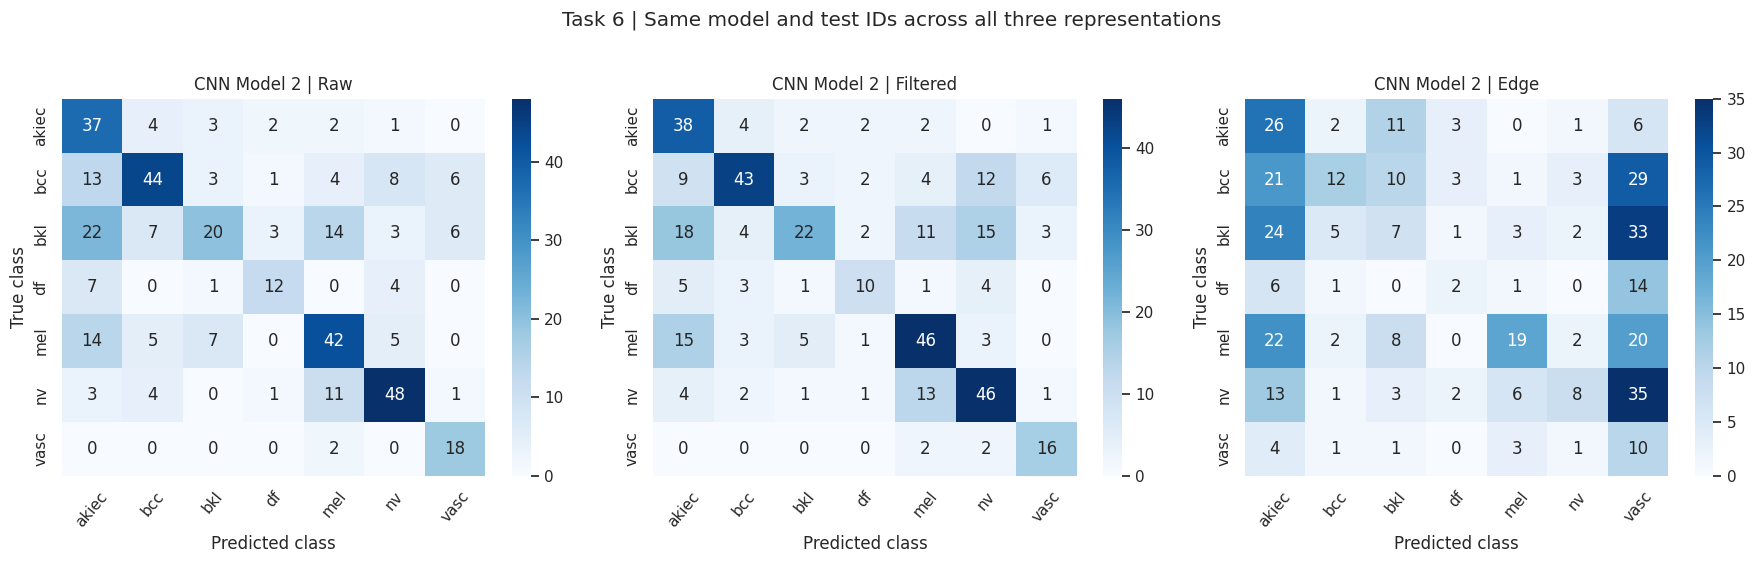

In [78]:
validation_summary=full_results.groupby('Model')['Validation F1'].mean().sort_values(ascending=False)
chosen_model=validation_summary.index[0]
print('Selected model using mean VALIDATION macro F1 only:',chosen_model)
display(validation_summary.rename('Mean validation macro F1').to_frame().round(4))
fig,axes=plt.subplots(1,3,figsize=(18,5.5))
for ax,version in zip(axes,['Raw','Filtered','Edge']):
    cm=confusion_matrix(y_all[split_masks['test']],predictions[(chosen_model,version)],
                        labels=np.arange(len(labels)))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=labels,yticklabels=labels,ax=ax)
    ax.set_title(f'{chosen_model} | {version}')
    ax.set_xlabel('Predicted class');ax.set_ylabel('True class')
    ax.tick_params(axis='x',rotation=50)
plt.suptitle('Task 6 | Same model and test IDs across all three representations',y=1.02)
plt.tight_layout();plt.savefig(OUTPUT_DIR/'task6_confusion_matrices.png',dpi=180,bbox_inches='tight');plt.show()

###  Plot all four test metrics for the selected model

**What this code does:** draws grouped bars for test accuracy, macro precision, macro recall, and macro F1 for raw, filtered and edge inputs. A score difference applies to this one selected split and these model settings; do not assume it generalizes to other datasets. Check the full results CSV for the other four models.

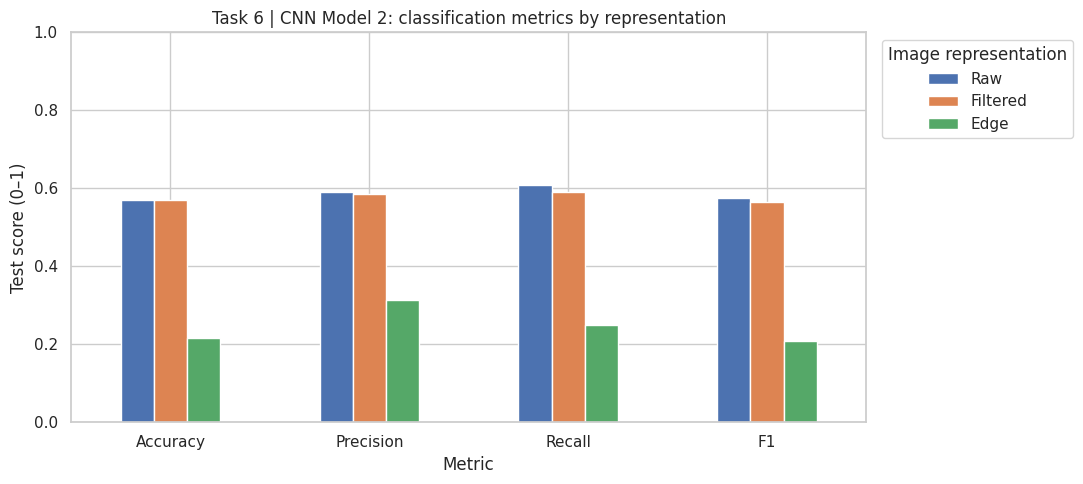

Representation,Raw,Filtered,Edge
Accuracy,0.5696,0.5696,0.2165
Precision,0.5899,0.5849,0.3136
Recall,0.6086,0.5909,0.2482
F1,0.5750,0.5647,0.2072


In [79]:
metrics=['Accuracy','Precision','Recall','F1']
subset=full_results.loc[full_results['Model'].eq(chosen_model)].set_index('Representation')
plot_values=subset.loc[['Raw','Filtered','Edge'],metrics].T
ax=plot_values.plot(kind='bar',figsize=(11,5),ylim=(0,1),rot=0)
ax.set_title(f'Task 6 | {chosen_model}: classification metrics by representation')
ax.set_xlabel('Metric');ax.set_ylabel('Test score (0–1)')
ax.legend(title='Image representation',bbox_to_anchor=(1.01,1),loc='upper left')
plt.tight_layout();plt.savefig(OUTPUT_DIR/'task6_metric_comparison.png',dpi=180,bbox_inches='tight');plt.show()
display(plot_values.round(4))

###  Examine the six CNN learning curves

**What this code does:** plots training and validation accuracy by epoch for each architecture/input pair. If training accuracy rises while validation accuracy falls or stalls, the model may be fitting details of the training set rather than generalizing. A short eight-epoch run may also **underfit**; a flat curve alone does not prove the image representation is poor.

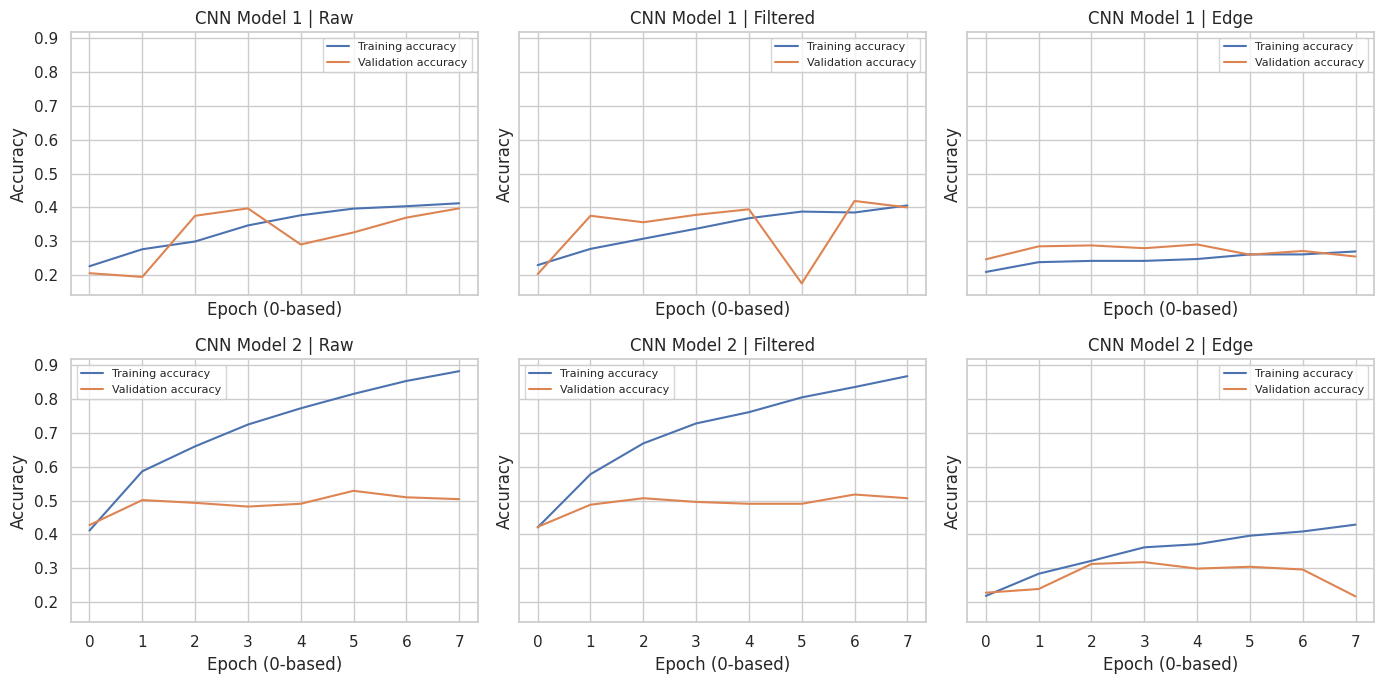

In [80]:
fig,axes=plt.subplots(2,3,figsize=(14,7),sharex=True,sharey=True)
for row,model_name in enumerate(['CNN Model 1','CNN Model 2']):
    for col,version in enumerate(['Raw','Filtered','Edge']):
        history=train_histories[(model_name,version)]
        ax=axes[row,col]
        ax.plot(history['accuracy'],label='Training accuracy')
        ax.plot(history['val_accuracy'],label='Validation accuracy')
        ax.set_title(f'{model_name} | {version}')
        ax.set_xlabel('Epoch (0-based)');ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
plt.tight_layout();plt.savefig(OUTPUT_DIR/'cnn_training_curves.png',dpi=180,bbox_inches='tight');plt.show()

## Report — Generate a draft from the measured results

###  Produce the required short report

**What this code does:** writes introduction, methodology, setup, results, discussion, conclusion and references to a Markdown file. The model scores come from **your actual run**. The questions about edge quality stay as prompts, because a numerical proxy cannot decide whether the boundaries are meaningful. After running, complete those observation prompts with your own figures and Table 1/2 evidence before submission.

In [81]:
chosen_scores=subset.loc[['Raw','Filtered','Edge'], ['Accuracy','Precision','Recall','F1']]
raw_acc=float(chosen_scores.loc['Raw','Accuracy'])
filtered_acc=float(chosen_scores.loc['Filtered','Accuracy'])
edge_acc=float(chosen_scores.loc['Edge','Accuracy'])
best_rep=chosen_scores['F1'].idxmax()
report=f"""# Lab 03 — Edge Detection and Classification

## 1. Introduction
This experiment compares first- and second-order edge detectors and Canny,
then measures whether raw, filtered, or edge-only inputs change image classification performance.

## 2. Methodology
Use the same selected HAM10000 image IDs and labels for all three representations.
Process grayscale images with Sobel Gx/Gy/magnitude, Prewitt, Laplacian, LoG, and Canny.
Add Gaussian and salt-and-pepper noise; compare unfiltered, Gaussian-filtered,
and median-filtered edges. Evaluate four Canny configurations.
Train SVM, Random Forest, KNN, CNN Model 1, and CNN Model 2 separately on each representation.

## 3. Experimental Setup
Selected classes: {', '.join(labels)}.
Total images: {len(meta)}; split train/val/test: {', '.join(str(int(split_masks[s].sum())) for s in ('train','val','test'))}.
Lesion group separation checked: yes.
Image size: {IMAGE_SIZE[0]} x {IMAGE_SIZE[1]}; classical features: {CLASSICAL_SIZE[0]} x {CLASSICAL_SIZE[1]} grayscale.
Filtered input: {LAB02_FILTER}; selected edge input: {BEST_EDGE_METHOD}.
Canny settings: low={BEST_CANNY_LOW}, high={BEST_CANNY_HIGH}, Gaussian={BEST_CANNY_KERNEL} x {BEST_CANNY_KERNEL}.
CNN training: {EPOCHS} epochs, batch size {BATCH_SIZE}; seed={SEED}.
Compatible saved split reused: {bool(SPLIT_CSV_PATH)}. Earlier Lab 01 results use a different ISIC dataset and cannot be directly compared; historical Lab 02 results also use different model and split settings unless independently verified.

## 4. Results
Selected model (highest mean validation macro F1): {chosen_model}.
Same-model test accuracy — raw: {raw_acc:.4f}; filtered: {filtered_acc:.4f}; edge: {edge_acc:.4f}.
Same-model test macro F1 — raw: {chosen_scores.loc['Raw','F1']:.4f}; filtered: {chosen_scores.loc['Filtered','F1']:.4f}; edge: {chosen_scores.loc['Edge','F1']:.4f}.
Numerically highest test macro F1 among these three runs: {best_rep}.
Refer to task1_required_comparison.png, task2_*.png, task3_canny_settings.png,
task6_confusion_matrices.png, task6_metric_comparison.png, and Tables 1–3.

## 5. Discussion — answer seven required questions
1. **Edge detection and noise:** [INSPECT TASK 2 FIGURES: name the detector showing the most false/spurious edges under the same noise setting. Cite your Table 1 and images.]
2. **Filtering:** [COMPARE Gaussian and median for BOTH noise types. Mention edge preservation versus noise removal.]
3. **Canny settings:** [USE TABLE 2 pixel counts and figure: describe how higher thresholds and a larger kernel affected weak/connected edges.]
4. **Edge maps and classification:** For {chosen_model}, edge minus raw test accuracy = {edge_acc-raw_acc:+.4f} ({100*(edge_acc-raw_acc):+.2f} percentage points). Discuss image information preserved/lost; avoid causal claims beyond this experiment.
5. **Information loss:** Edge-only images discard most original color, intensity and texture information. These can be useful for differentiating visually similar classes.
6. **Classical vs. deep features:** CNNs can learn and combine low-level edge-like patterns with texture, shape and higher-level features suited to the labels, instead of relying exclusively on a fixed hand-crafted edge operator.
7. **Input representation:** For the chosen model, test macro F1: raw={chosen_scores.loc['Raw','F1']:.4f}, filtered={chosen_scores.loc['Filtered','F1']:.4f}, edge={chosen_scores.loc['Edge','F1']:.4f}. Identify the representation supported by your own scores and explain limitations (class balance, chosen split, model, and no repeated-run uncertainty intervals).

## 6. Conclusion
This experiment compared five edge detectors and three representations under shared image IDs and evaluation settings. The measured results above describe this dataset, model selection procedure and particular split. Their raw and filtered scores were retrained here and do not reproduce historical Lab 01 and 02 results.

## 7. References
- Course handout: *Lab 03: Edge Detection Techniques and Their Impact on Classification Performance* (provided by instructor).
- Tschandl, Rosendahl & Kittler (2018), HAM10000, *Scientific Data*, doi:10.1038/sdata.2018.161.
- OpenCV documentation, image gradients and Canny edge detection: https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html and https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html.
- scikit-learn documentation, classification metrics: https://scikit-learn.org/stable/modules/model_evaluation.html.
"""
(OUTPUT_DIR/'lab03_report_draft.md').write_text(report,encoding='utf-8')
display(Markdown(report))

# Lab 03 — Edge Detection and Classification

## 1. Introduction
This experiment compares first- and second-order edge detectors and Canny,
then measures whether raw, filtered, or edge-only inputs change image classification performance.

## 2. Methodology
Use the same selected HAM10000 image IDs and labels for all three representations.
Process grayscale images with Sobel Gx/Gy/magnitude, Prewitt, Laplacian, LoG, and Canny.
Add Gaussian and salt-and-pepper noise; compare unfiltered, Gaussian-filtered,
and median-filtered edges. Evaluate four Canny configurations.
Train SVM, Random Forest, KNN, CNN Model 1, and CNN Model 2 separately on each representation.

## 3. Experimental Setup
Selected classes: akiec, bcc, bkl, df, mel, nv, vasc.
Total images: 2584; split train/val/test: 1831, 365, 388.
Lesion group separation checked: yes.
Image size: 224 x 224; classical features: 32 x 32 grayscale.
Filtered input: gaussian; selected edge input: Canny.
Canny settings: low=50, high=150, Gaussian=3 x 3.
CNN training: 8 epochs, batch size 32; seed=42.
Compatible saved split reused: False. Earlier Lab 01 results use a different ISIC dataset and cannot be directly compared; historical Lab 02 results also use different model and split settings unless independently verified.

## 4. Results
Selected model (highest mean validation macro F1): CNN Model 2.
Same-model test accuracy — raw: 0.5696; filtered: 0.5696; edge: 0.2165.
Same-model test macro F1 — raw: 0.5750; filtered: 0.5647; edge: 0.2072.
Numerically highest test macro F1 among these three runs: Raw.
Refer to task1_required_comparison.png, task2_*.png, task3_canny_settings.png,
task6_confusion_matrices.png, task6_metric_comparison.png, and Tables 1–3.

## 5. Discussion — answer seven required questions
1. **Edge detection and noise:** [INSPECT TASK 2 FIGURES: name the detector showing the most false/spurious edges under the same noise setting. Cite your Table 1 and images.]
2. **Filtering:** [COMPARE Gaussian and median for BOTH noise types. Mention edge preservation versus noise removal.]
3. **Canny settings:** [USE TABLE 2 pixel counts and figure: describe how higher thresholds and a larger kernel affected weak/connected edges.]
4. **Edge maps and classification:** For CNN Model 2, edge minus raw test accuracy = -0.3531 (-35.31 percentage points). Discuss image information preserved/lost; avoid causal claims beyond this experiment.
5. **Information loss:** Edge-only images discard most original color, intensity and texture information. These can be useful for differentiating visually similar classes.
6. **Classical vs. deep features:** CNNs can learn and combine low-level edge-like patterns with texture, shape and higher-level features suited to the labels, instead of relying exclusively on a fixed hand-crafted edge operator.
7. **Input representation:** For the chosen model, test macro F1: raw=0.5750, filtered=0.5647, edge=0.2072. Identify the representation supported by your own scores and explain limitations (class balance, chosen split, model, and no repeated-run uncertainty intervals).

## 6. Conclusion
This experiment compared five edge detectors and three representations under shared image IDs and evaluation settings. The measured results above describe this dataset, model selection procedure and particular split. Their raw and filtered scores were retrained here and do not reproduce historical Lab 01 and 02 results.

## 7. References
- Course handout: *Lab 03: Edge Detection Techniques and Their Impact on Classification Performance* (provided by instructor).
- Tschandl, Rosendahl & Kittler (2018), HAM10000, *Scientific Data*, doi:10.1038/sdata.2018.161.
- OpenCV documentation, image gradients and Canny edge detection: https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html and https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html.
- scikit-learn documentation, classification metrics: https://scikit-learn.org/stable/modules/model_evaluation.html.


###  Export ALL results so you can submit them

**What this does:** creates one ZIP with tables, figures, the generated split CSV, full model metrics, and the report draft.

In [82]:
import shutil
archive=shutil.make_archive('/content/lab03_results','zip',root_dir=str(OUTPUT_DIR))
print('Saved result archive:',archive)
print('Files included:')
for p in sorted(OUTPUT_DIR.iterdir()): print('  ',p.name)
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print('Not in Google Colab: download the archive from your runtime file browser.')

Saved result archive: /content/lab03_results.zip
Files included:
   all_15_experiments.csv
   cnn_training_curves.png
   lab03_report_draft.md
   lab03_split.csv
   table1_noise_preprocessing.csv
   table2_canny_parameters.csv
   table3_cross_representation.csv
   task1_required_comparison.png
   task2_gaussian_edge_maps.png
   task2_noise_and_filters.png
   task2_salt_and_pepper_edge_maps.png
   task3_canny_settings.png
   task4_three_representations.png
   task6_confusion_matrices.png
   task6_metric_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>